# MASTER THESIS - model V4

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiTmCn3R2C grey-box model on a summer period (1st of September to 15th of September) where there is no heating at all

## Importation

In [3]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

Our temporal resolution is 5 minutes

In [4]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [5]:
input_df = pd.read_csv('./data/data_summer.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_SpTI01_C']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Tsup', 'Ti0', 'Tm0', 'c0', 'N0']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (4296, 9), input y shape: (4296,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (3436, 9), y shape: (3436,)
Test: X shape: (860, 9), y shape: (860,)


## Model Training Parameters and Physical Constants

The following section defines the physical parameters and initial conditions used for fitting the thermal model. These parameters are based on building geometry, HVAC design standards, and physical constants:

- **Room Surface Area (`S_room`)** (from Revit model)
- **Window Area (`A_windows`)** (from Revit model)
- **Room Height (`H_room`)**: 2.7 m (from Revit model)

   

### Model Parameter Dictionary

The `train_params_TiThTmTrcn3R3C` dictionary contains all model parameters, including:

- Initial conditions for temperatures, CO₂, occupancy, and flow rates
- Thermal capacitances and resistances for air, heater, mass, and envelope
- Internal gains from people and equipment
- Physical constants (air density, specific heat, gravity, etc.)
- Maximum water flow rate (`Phi_max`), allowed to vary between 50% and 150% of the estimated value

These parameters are passed to the model fitting pipeline to calibrate the thermal model to the observed data. The stability of the simulation is verified by printing the time step (`rec_duration`).




In [8]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)



# Capacitances initial guesses
# C=ρ×V×c_p [J/K] (ρ density kg/m³, V volume m³, c_p specific heat capacity J/kgK)
rho_air_init = 1.2          # kg/m³
cp_air_init = 1005          # J/kgK
rho_furn_init = 500         # kg/m³
cp_furn_init = 1200         # J/kgK
V_furn_init = 0.1 * V_room  # m³  (10% of room volume as furniture/contents volume)
Ci_i = rho_air_init * V_room * cp_air_init + rho_furn_init * V_furn_init * cp_furn_init

rho_wall = 2200             # kg/m³
cp_conc  = 840              # J/kgK
wall_thickness = 0.1        # m
Cm_i = rho_wall * (S_room * wall_thickness) * cp_conc  



# Resistances initial guesses
# R=1/(U*A) or 1/(h*A) [K/W]
h_conv = 8                     # W/m²K
S_int_mass = 0.6 * S_room      # internal surfaces area ~60%
Rim_i = 1 / (h_conv * S_int_mass)

U_env = 0.25                   # W/m²K
Rout_i= 1 / (U_env * S_room)


# Capacitances and resistances variation ranges
# WIDENED based on optimizer hitting bounds (see diagnostic cell)
Ci_min = 0.05*Ci_i      # Was 0.2x → lowered (optimizer wanted smaller)
Ci_max = 2*Ci_i         # Keep similar
Cm_min = 0.1*Cm_i       # Was 0.5x → lowered (optimizer wanted smaller)
Cm_max = 3*Cm_i         # Keep similar

Rim_min = 0.2*Rim_i     # Slightly lower
Rim_max = 2*Rim_i       # Keep similar
Rout_min = 0.1*Rout_i   # Was 0.5x → lowered (optimizer wanted more heat loss)
Rout_max = 2*Rout_i     # Keep similar



# Define training parameters
train_params_TiThTmTrcn3R3C = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 5000, 'vary': True, 'min': 1000, 'max': 50000},
    'Cm': {'value': 100000, 'vary': True, 'min': 10000, 'max': 1000000},  # Bigger mass\n",
    'Rim': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 1.0},        # Mass-air  \n",
    'Rout': {'value': 0.15, 'vary': True, 'min': 0.01, 'max': 2.0},      # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    'g': {'value': 0.35, 'vary': False},                                    # Some constant g
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [10]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
}

error_metric = rmse

method = 'nelder'

models = [TiTmCn2R2C_summer(train_params_TiThTmTrcn3R3C, rec_duration)]

Now, it is time to run the simulation:

In [17]:
# Run the darkgreyfit
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method=method,
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

df

model = df.iloc[0][('train', 'model')]
train_results = df.iloc[0][('train', 'model_result')]
test_results = df.iloc[0][('test', 'model_result')]

# Display model parameters safely
if hasattr(model, "result") and hasattr(model.result, "params"):
    display(model.result.params)
else:
    print("Model parameters not available.")

2026-01-22 18:35:50,247 darkgreybox  INFO     Training models...
2026-01-22 18:36:07,555 darkgreybox  INFO     Generating predictions for 1 models...
Fitting complete!
DataFrame shape: (1, 13)


name,value,initial value,min,max,vary
Ti0,23.8000000,25.36727273,-inf,inf,False
Tm0,24.4240868,25.36727273,-inf,inf,False
c0,400.318398,433.68,-inf,inf,False
N0,7.5307e-33,0.0,-inf,inf,False
Ci,6970.12129,5000.0,1000.00000,50000.0000,True
Cm,10878.5886,100000.0,10000.0000,1000000.00,True
Rim,0.01000000,0.1,0.01000000,1.00000000,True
Rout,0.06209085,0.15,0.01000000,2.00000000,True
q_pers,75.0000000,75.0,-inf,inf,False
q_equip_var,80.0000000,80.0,-inf,inf,False


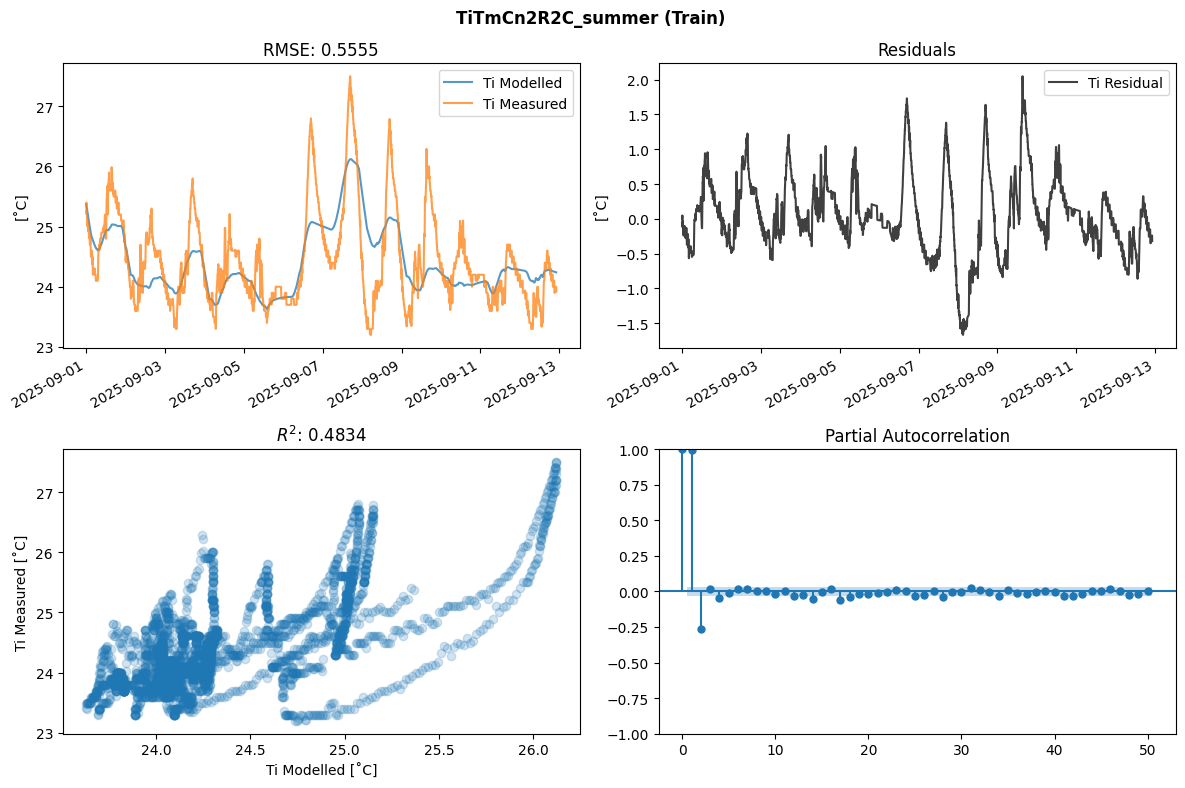

In [18]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

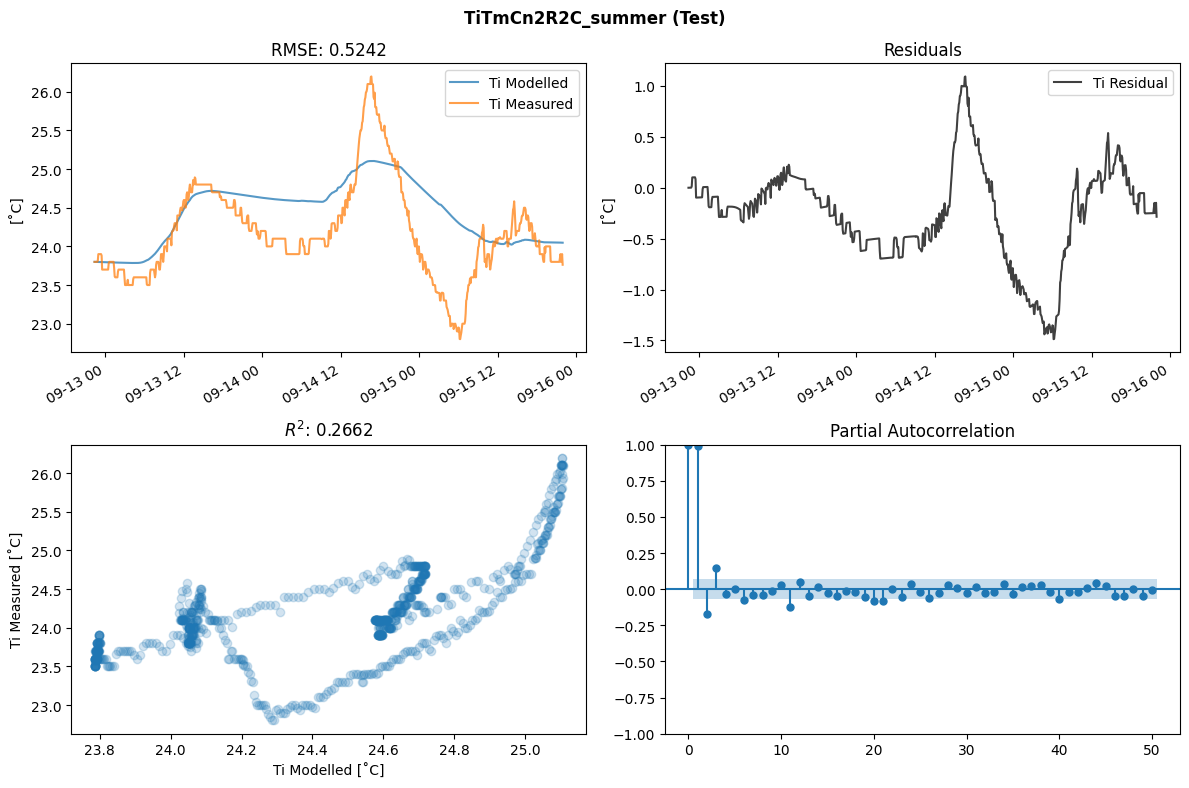

In [19]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

In [ ]:
# Extract Q_int, Q_vent, and Q_solar from train and test results
Q_int_train = train_results.var['Q_int']
Q_vent_train = train_results.var['Q_vent']
Q_solar_train = train_results.var['Q_solar']

Q_int_test = test_results.var['Q_int']
Q_vent_test = test_results.var['Q_vent']
Q_solar_test = test_results.var['Q_solar']

# Concatenate train and test for full time series
Q_int_full = np.concatenate([Q_int_train, Q_int_test])
Q_vent_full = np.concatenate([Q_vent_train, Q_vent_test])
Q_solar_full = np.concatenate([Q_solar_train, Q_solar_test])

# Get full index from y_train and y_test
full_index = y_train.index.append(y_test.index)

plt.figure(figsize=(14, 6))
plt.plot(full_index, Q_int_full, label='Q_int (Internal Gains)')
plt.plot(full_index, Q_vent_full, label='Q_vent (Ventilation Gains)')
plt.plot(full_index, Q_solar_full, label='Q_solar (Solar Gains)')
plt.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
plt.xlabel('Time')
plt.ylabel('Power (W)')
plt.title('Model Heat Gains: Q_int, Q_vent, Q_solar')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Using the Kalman Filter Model for Occupancy Estimation

The `TiTmxvCN2R2C_KF` model extends the base model with a Kalman filter that updates the occupancy estimate N at each timestep based on CO2 observations. This allows N to vary over time instead of staying constant.

In [ ]:
# Reload the models module to get the new TiTmxvCN2R2C_KF class
importlib.reload(sys.modules['darkgreybox.models'])
from darkgreybox.models import TiTmxvCN2R2C_KF

# Add the CO2 observations to the input data for the Kalman filter
input_df['C_obs'] = input_df['C']  # Use measured CO2 as observations
input_df['P_N0'] = 1.0  # Initial variance of N estimate (constant for all rows)

# Update input_X to include C_obs and P_N0
input_X_kf = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]

# Split for KF model
X_train_kf, X_test_kf, _, _ = train_test_split(input_X_kf, input_y, test_size=0.2, shuffle=False)

# Add Kalman filter parameters to the training params
train_params_KF = train_params_TiTmxvCN2R2C.copy()
train_params_KF['Q_N'] = {'value': 0.5, 'vary': False}     # Process noise for N (persons²/h)
train_params_KF['R_C'] = {'value': 50.0, 'vary': False}    # Measurement noise for CO2 (ppm²)
train_params_KF['P_N0'] = {'value': 1.0, 'vary': False}    # Initial variance of N

print("Training parameters for Kalman Filter model:")
print(f"  Q_N (process noise): {train_params_KF['Q_N']['value']}")
print(f"  R_C (measurement noise): {train_params_KF['R_C']['value']}")

KeyError: 'C'

In [ ]:
# Create and fit the Kalman Filter model
models_kf = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

# Update ic_params_map for KF model
ic_params_map_kf = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: train_result.var['N'][-1],  # Use last estimated N
    'P_N0': lambda X_test, y_test, train_result: train_result.var['P_N'][-1],  # Use last variance
}

df_kf = darkgreyfit(
    models=models_kf,
    X_train=X_train_kf,
    y_train=y_train,
    X_test=X_test_kf,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Kalman Filter model training complete!")

2026-01-18 16:28:37,879 darkgreybox  INFO     Training models...
2026-01-18 16:31:30,650 darkgreybox  INFO     Generating predictions for 1 models...
Kalman Filter model training complete!


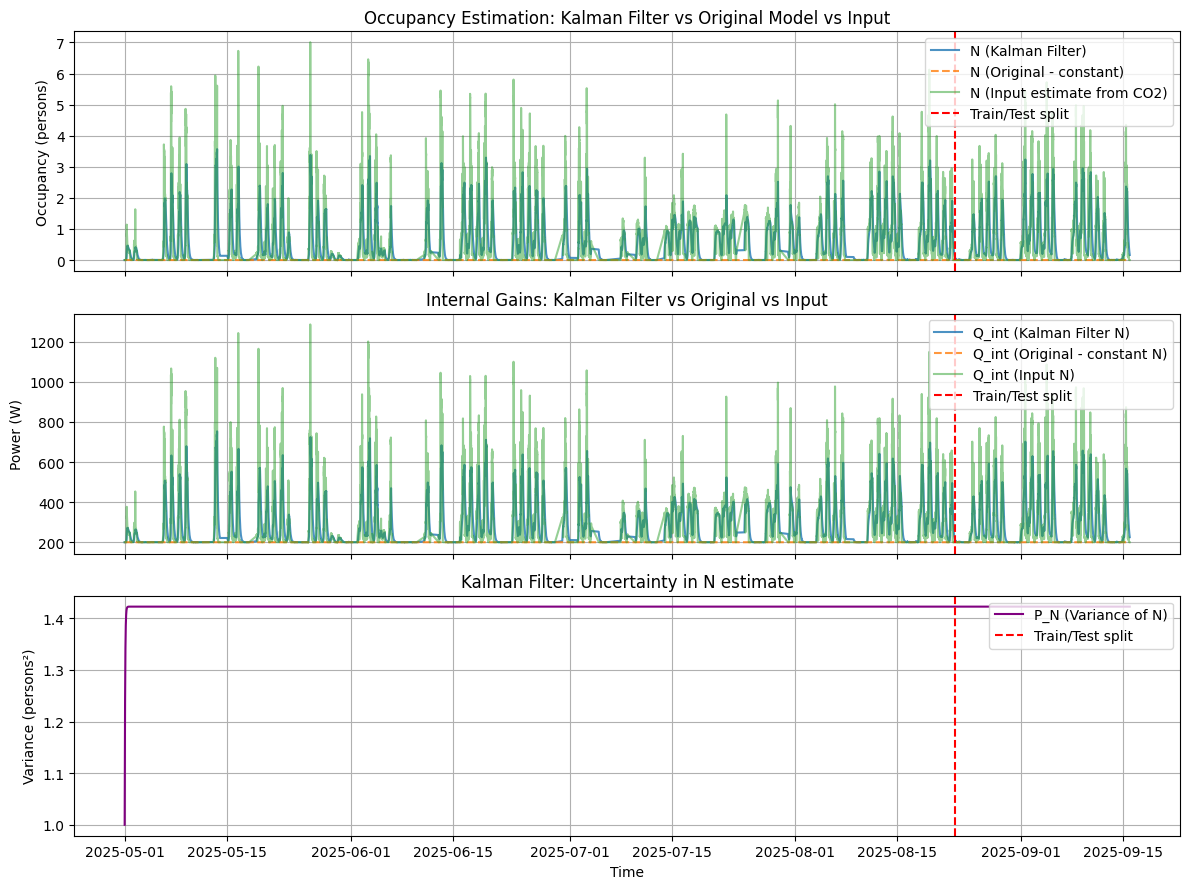


--- Model Comparison ---
Original Model - Train RMSE: 0.6694°C
Original Model - Test RMSE:  0.5648°C
Kalman Filter  - Train RMSE: 0.7193°C
Kalman Filter  - Test RMSE:  0.6548°C


In [ ]:
# Extract results from Kalman Filter model
select_idx_kf = df_kf[('train', 'error')].argmin()
model_kf = df_kf.loc[select_idx_kf, ('train', 'model')]
train_results_kf = df_kf.loc[select_idx_kf, ('train', 'model_result')]
test_results_kf = df_kf.loc[select_idx_kf, ('test', 'model_result')]

# Extract N from original model (non-KF)
N_train = train_results.var['N']
N_test = test_results.var['N']

# Compare N from original model vs Kalman Filter model
N_kf_train = train_results_kf.var['N']
N_kf_test = test_results_kf.var['N']
N_kf_full = np.concatenate([N_kf_train, N_kf_test])

# Get parameters for Q_int calculation
q_pers = train_params_TiTmxvCN2R2C['q_pers']['value']
q_equip_var = train_params_TiTmxvCN2R2C['q_equip_var']['value']
Q_int_const = train_params_TiTmxvCN2R2C['Q_int_const']['value']

# Plot comparison of N estimates
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

idx = input_y.index

# Plot 1: N comparison
axes[0].plot(idx, N_kf_full, label='N (Kalman Filter)', alpha=0.8)
axes[0].plot(idx, np.concatenate([N_train, N_test]), label='N (Original - constant)', linestyle='--', alpha=0.8)
axes[0].plot(input_df.loc[idx, 'N'], label='N (Input estimate from CO2)', alpha=0.5)
axes[0].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[0].set_ylabel('Occupancy (persons)')
axes[0].set_title('Occupancy Estimation: Kalman Filter vs Original Model vs Input')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Q_int comparison
Q_int_kf = Q_int_const + (q_pers + q_equip_var) * N_kf_full
Q_int_orig = Q_int_const + (q_pers + q_equip_var) * np.concatenate([N_train, N_test])
Q_int_input = Q_int_const + (q_pers + q_equip_var) * input_df.loc[idx, 'N'].values
axes[1].plot(idx, Q_int_kf, label='Q_int (Kalman Filter N)', alpha=0.8)
axes[1].plot(idx, Q_int_orig, label='Q_int (Original - constant N)', linestyle='--', alpha=0.8)
axes[1].plot(idx, Q_int_input, label='Q_int (Input N)', alpha=0.5)
axes[1].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[1].set_ylabel('Power (W)')
axes[1].set_title('Internal Gains: Kalman Filter vs Original vs Input')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Variance of N (uncertainty)
P_N_train = train_results_kf.var['P_N']
P_N_test = test_results_kf.var['P_N']
P_N_full = np.concatenate([P_N_train, P_N_test])
axes[2].plot(idx, P_N_full, label='P_N (Variance of N)', color='purple')
axes[2].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[2].set_ylabel('Variance (persons²)')
axes[2].set_xlabel('Time')
axes[2].set_title('Kalman Filter: Uncertainty in N estimate')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print RMSE comparison
print(f"\n--- Model Comparison ---")
print(f"Original Model - Train RMSE: {df.loc[select_idx, ('train', 'error')]:.4f}°C")
print(f"Original Model - Test RMSE:  {df.loc[select_idx, ('test', 'error')]:.4f}°C")
print(f"Kalman Filter  - Train RMSE: {df_kf.loc[select_idx_kf, ('train', 'error')]:.4f}°C")
print(f"Kalman Filter  - Test RMSE:  {df_kf.loc[select_idx_kf, ('test', 'error')]:.4f}°C")

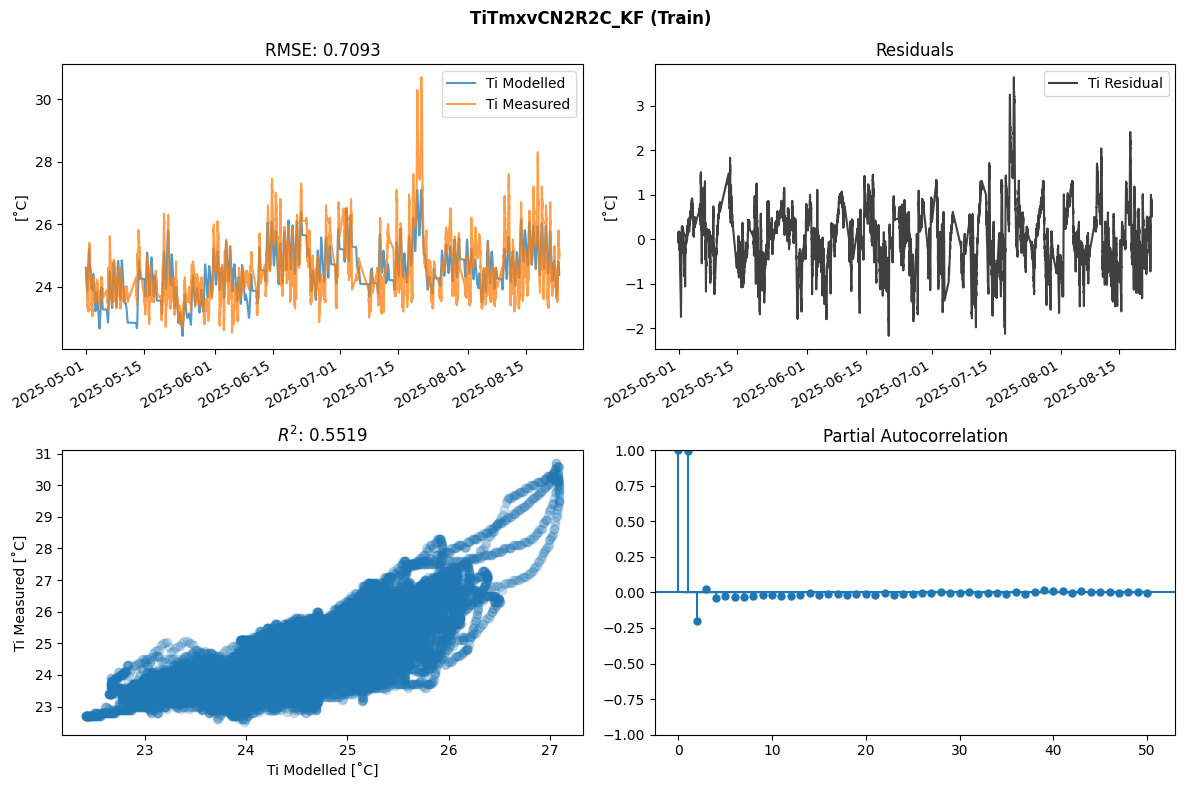

In [ ]:
# Plot Train results for Kalman Filter model
plot(y_train, train_results_kf, 'TiTmxvCN2R2C_KF (Train)')

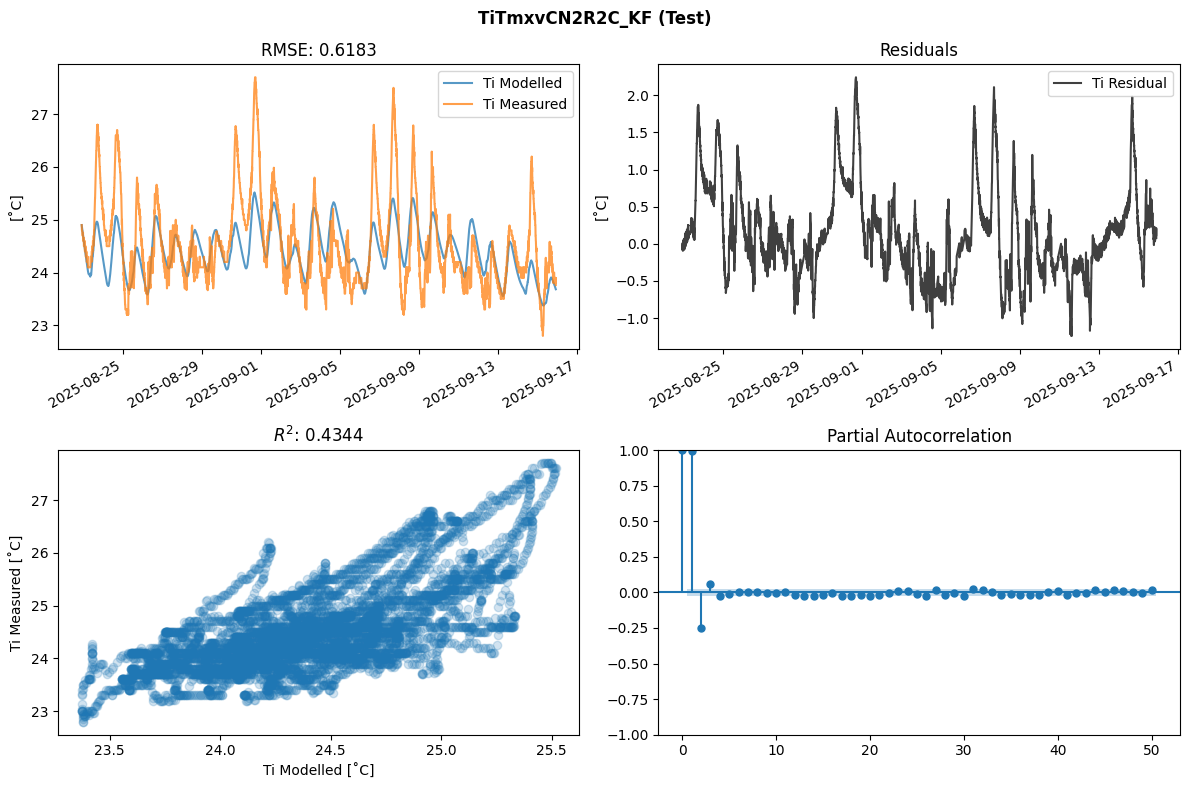

In [ ]:
# Plot Test results for Kalman Filter model
plot(y_test, test_results_kf, 'TiTmxvCN2R2C_KF (Test)')